In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

In [71]:
csvfile = "https://raw.githubusercontent.com/mpferreira003/SME0130-RedesComplexas/refs/heads/SIR/dataset/socialInteraction.dat"

df = pd.read_csv(csvfile, sep='\s+', header=None, names=['source', 'target', 'timestamp'])
df.head()


,source,target,timestamp
0,1558,1567,0
1,1560,1570,0
2,1567,1574,0
3,1632,1818,0
4,1632,1866,0


In [72]:
from os import stat
def SIR_temporal(df, seed, beta=0.3, mu=1.0, N=None):

      #df (pd.DataFrame): Temporal edge list with columns ['source', 'target', 'timestamp']
      #seed (int): Index of the seed node
      #beta (float): Infection probability
      #mu (float): Recovery probability
      #N (int): Number of nodes in the network (optional, inferred if not provided)
      #Returns Lists of infected, susceptible, recovered fractions over time and corresponding time steps


    if N is None:
        N = max(df['source'].max(), df['target'].max()) + 1

    #states: 0=S, 1=I, 2=R
    print('Number of nodes: ' , N)
    states = np.zeros(N)
    states[seed] = 1  # infect the seed
    print('Seed: ', seed)
    print('Infected: ', states)

    vI, vS, vR, vt = [], [], [], []
    state_matrix = []

    timestamps = sorted(df['timestamp'].unique())
    for t in timestamps:

      current_edges = df[df['timestamp'] == t][['source', 'target']].values
      infected = np.where(states == 1)[0]

      print('Timestamp:', t)
      print('Infected:', infected)

      #infection
      new_infected = []
      for u, v in current_edges:
          if states[u] == 1 and states[v] == 0 and np.random.rand() < beta:
              new_infected.append(v)
          elif states[v] == 1 and states[u] == 0 and np.random.rand() < beta:
              new_infected.append(u)

      for node in new_infected:
          states[node] = 1

      #reecovery step
      for i in infected:
          if np.random.rand() < mu:
              states[i] = 2 #if node recovered map with number "2"

      nI = np.sum(states == 1)
      nR = np.sum(states == 2)
      nS = np.sum(states == 0)

      vI.append(nI / N)
      vS.append(nS / N)
      vR.append(nR / N)
      vt.append(t)

      state_matrix.append(states.copy())

      if nI == 0:
          break
    #also return a matrix as discussed in yesterday's meeting.
    matrix = np.vstack(state_matrix)

    return vI, vS, vR, vt, matrix


In [73]:
def createMapping(df, seed_node_id):
  unique_nodes = sorted(set(df['source']).union(set(df['target'])))
  id_to_idx = {node_id: idx for idx, node_id in enumerate(unique_nodes)}

  df_mapped = df.copy()
  df_mapped['source'] = df['source'].map(id_to_idx)
  df_mapped['target'] = df['target'].map(id_to_idx)

  seed = id_to_idx[seed_node_id]

  return (df_mapped, seed, len(unique_nodes))


In [74]:
df_mapped, seed, N_nodes = createMapping(df, seed_node_id=1558)
vI, vS, vR, vt, matrix = SIR_temporal(df_mapped, seed=seed, beta=0.9, mu=0.01, N=N_nodes)


Number of nodes:  236
Seed:  58
Infected:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Timestamp: 0
Infected: [58]
Timestamp: 1
Infected: [58 63]
Timestamp: 2
Infected: [58 63]
Timestamp: 3
Infected: [58 62 63 66]
Timestamp: 4
Infected: [58 62 63 66]
Timestamp: 5
Infected: [58 62 63 66]
Timestamp: 6
Infected: [58 62 63 66]


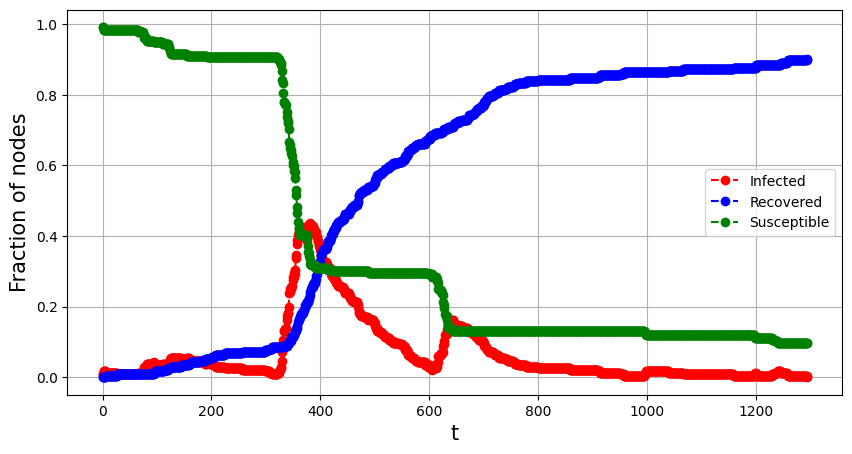

In [75]:
plt.figure(figsize=(10,5))
plt.plot(vt, vI, 'ro--', label='Infected')
plt.plot(vt, vR, 'bo--', label='Recovered')
plt.plot(vt, vS, 'go--', label='Susceptible')
plt.xlabel("t", fontsize=15)
plt.ylabel("Fraction of nodes", fontsize=15)
plt.legend()
plt.grid(True)
plt.show(True)

In [76]:
df_matrix = pd.DataFrame(matrix)
print(df_matrix)
df_matrix.to_csv('combined_state_matrix.csv', index=False)

      0    1    2    3    4    5    6    7    8    9    ...  226  227  228  \
0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
1290  2.0  0.0  2.0  2.0  0.0  2.0  2.0  0.0  2.0  2.0  ...  2.0  2.0  2.0   
1291  2.0  0.0  2.0  2.0  0.0  2.0  2.0  0.0  2.0  2.0  ...  2.0  2.0  2.0   
1292  2.0  0.0  2.0  2.0  0.0  2.0  2.0  0.0  2.0  2.0  ...  2.0  2.0  2.0   
1293  2.0  0.0  2.0  2.0  0.0  2.0  2.0  0.0  2.0  2.0  ...  2.0  2.0  2.0   
1294  2.0  0.0  2.0  2.0  0.0  2.0  2.0  0.0  2.0  2.0  ...  2.0  2.0  2.0   

      229  230  231  232  233  234  235  
0     0.0  0.0  0.0  